# regDL-TCIP visualization notebook

Goal: minimize required inputs to load model + data and run inference at `(N, F)` (first two data dims).

Minimum inputs:
- `MODEL_CONFIG_PATH`
- `MODEL_CHECKPOINT_PATH`
- `DATA_SOURCE` (`temp_dir` with `train/val/test.npy` or direct `.npy` [N,F,H,W,C])
- `SAMPLE_N`, `SAMPLE_F`


In [3]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / 'module').exists() and (p / 'configs').exists():
            return p
    fallback = Path('/N/u/kmluong/BigRed200/regDL-TCIP')
    if fallback.exists():
        return fallback
    raise FileNotFoundError('Cannot find repo root (folder containing module/ and configs/).')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from visualization.model_loader import load_model_from_paths
from module.training.datasets import load_split_arrays
from module.training.masks import extract_bc_rim_from_y, make_rim_mask_like, make_smooth_phi

print('REPO_ROOT =', REPO_ROOT)


REPO_ROOT = /geode2/home/u050/kmluong/BigRed200/regDL-TCIP


In [4]:
# ===== User inputs (minimum) =====
MODEL_CONFIG_PATH = '/N/slate/kmluong/regDL-TCIP/IDEALIZED/checkpoints/AFNO-TCP-NO-BC.json'
MODEL_CHECKPOINT_PATH = '/N/slate/kmluong/regDL-TCIP/IDEALIZED/checkpoints/trained-AFNO-TCP-NO-BC.pt'
DATA_SOURCE = '/N/slate/kmluong/regDL-TCIP/IDEALIZED/tmp'
SAMPLE_N = 0
SAMPLE_F = 0

# ===== Optional =====
SPLIT = 'test'         # used if DATA_SOURCE is temp dir: train/val/test
RIM = 1                # used for BC architecture
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CHANNEL_TO_SHOW = 0

print('DEVICE =', DEVICE)


DEVICE = cpu


In [5]:
def load_data_array(data_source: str | Path, split: str = 'test'):
    p = Path(data_source)
    if p.is_dir():
        train, val, test = load_split_arrays(p)
        split = split.lower()
        if split == 'train':
            arr = train
        elif split == 'val':
            if val is None:
                raise ValueError('No val.npy found in this temp dir.')
            arr = val
        elif split == 'test':
            arr = test
        else:
            raise ValueError(f'Invalid split: {split}')
        source_kind = f'temp_dir:{split}'
    else:
        if p.suffix != '.npy':
            raise ValueError(f'DATA_SOURCE must be temp dir or .npy file, got: {p}')
        arr = np.load(p, mmap_mode='r')
        source_kind = 'npy'

    if arr.ndim != 5:
        raise ValueError(f'Data must have shape [N,F,H,W,C], got: {arr.shape}')

    return arr, source_kind


def make_window_tensors(arr, n_idx: int, f_idx: int, step_in: int, device: str):
    N, F, H, W, C = arr.shape
    if not (0 <= n_idx < N):
        raise IndexError(f'SAMPLE_N out of range [0, {N-1}]')
    if not (0 <= f_idx <= F - step_in - 1):
        raise IndexError(
            f'SAMPLE_F out of range [0, {F-step_in-1}] to keep a valid target frame (F={F}, step_in={step_in})'
        )

    x_np = arr[n_idx, f_idx : f_idx + step_in, ...]
    y_np = arr[n_idx, f_idx + step_in, ...]

    # [T,H,W,C] -> [1,T,C,H,W]
    x = torch.from_numpy(np.transpose(x_np, (0, 3, 1, 2)).copy()).float().unsqueeze(0).to(device)
    # [H,W,C] -> [1,C,H,W]
    y = torch.from_numpy(np.transpose(y_np, (2, 0, 1)).copy()).float().unsqueeze(0).to(device)
    return x, y


In [6]:
# 1) Load model from 2 paths (json + pt)
model, meta = load_model_from_paths(
    config_path=MODEL_CONFIG_PATH,
    checkpoint_path=MODEL_CHECKPOINT_PATH,
    map_location=DEVICE,
    strict=True,
    eval_mode=True,
)
model = model.to(DEVICE)
cfg = meta['config']

# 2) Load data [N,F,H,W,C]
arr, source_kind = load_data_array(DATA_SOURCE, split=SPLIT)

# 3) Build one window from (N,F)
step_in = int(cfg['num_times'])
x, y_true = make_window_tensors(arr, SAMPLE_N, SAMPLE_F, step_in=step_in, device=DEVICE)

print('source_kind =', source_kind)
print('data shape =', arr.shape, '[N,F,H,W,C]')
print('x shape =', tuple(x.shape), '[B,T,C,H,W]')
print('y_true shape =', tuple(y_true.shape), '[B,C,H,W]')
print('architecture =', cfg['architecture'])


source_kind = temp_dir:test
data shape = (1, 480, 100, 100, 12) [N,F,H,W,C]
x shape = (1, 3, 12, 100, 100) [B,T,C,H,W]
y_true shape = (1, 12, 100, 100) [B,C,H,W]
architecture = afno_no_bc


In [7]:
def run_inference_one_window(model, cfg, x, y_true, rim: int = 1):
    arch = str(cfg.get('architecture', '')).lower()
    is_bc = arch in {'afno_v1'}

    with torch.no_grad():
        x_in = x
        y_in = y_true

        # Match training pipeline: normalize when scaler exists
        if getattr(model, 'x_scaler', None) is not None:
            x_in = model.x_scaler.norm(x_in)
        if getattr(model, 'y_scaler', None) is not None:
            y_in = model.y_scaler.norm(y_in)

        if is_bc:
            b_fill = extract_bc_rim_from_y(y_in, rim=rim)
            bc_mask = make_rim_mask_like(y_in, rim=rim)
            bc_in = torch.cat([b_fill, bc_mask], dim=1)
            y_free = model(x_in, bc_in)

            phi = make_smooth_phi(
                H=y_in.shape[-2], W=y_in.shape[-1], rim=rim,
                device=y_in.device, dtype=y_in.dtype,
            )
            y_pred_norm = phi * y_free + (1.0 - phi) * b_fill
        else:
            y_pred_norm = model(x_in)

        if getattr(model, 'y_scaler', None) is not None:
            y_pred = model.y_scaler.denorm(y_pred_norm)
            y_true_out = y_true
        else:
            y_pred = y_pred_norm
            y_true_out = y_true

    return y_pred, y_true_out


y_pred, y_ref = run_inference_one_window(model, cfg, x, y_true, rim=RIM)
mae = (y_pred - y_ref).abs().mean().item()
mse = torch.mean((y_pred - y_ref) ** 2).item()

print(f'Sample (N={SAMPLE_N}, F={SAMPLE_F}) done')
print('y_pred shape =', tuple(y_pred.shape))
print(f'MAE = {mae:.6f}, MSE = {mse:.6f}')


Sample (N=0, F=0) done
y_pred shape = (1, 12, 100, 100)
MAE = 0.099819, MSE = 0.102980


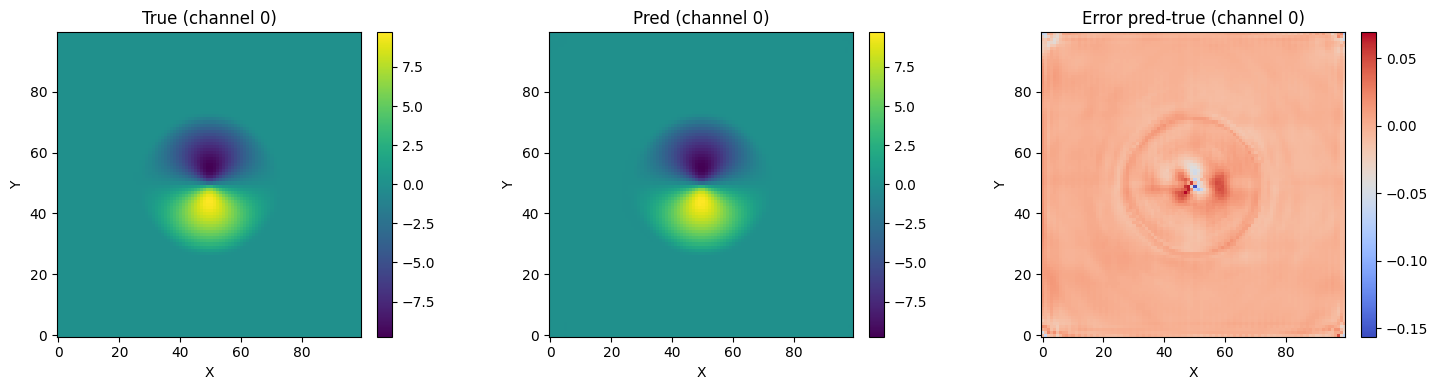

In [8]:
# Quick visualization for one channel
c = int(CHANNEL_TO_SHOW)
if c < 0 or c >= y_pred.shape[1]:
    raise IndexError(f'CHANNEL_TO_SHOW must be in [0, {y_pred.shape[1]-1}]')

pred_map = y_pred[0, c].detach().cpu().numpy()
true_map = y_ref[0, c].detach().cpu().numpy()
err_map = pred_map - true_map

vmin = min(pred_map.min(), true_map.min())
vmax = max(pred_map.max(), true_map.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(true_map, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
axes[0].set_title(f'True (channel {c})')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(pred_map, origin='lower', vmin=vmin, vmax=vmax, cmap='viridis')
axes[1].set_title(f'Pred (channel {c})')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(err_map, origin='lower', cmap='coolwarm')
axes[2].set_title(f'Error pred-true (channel {c})')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()


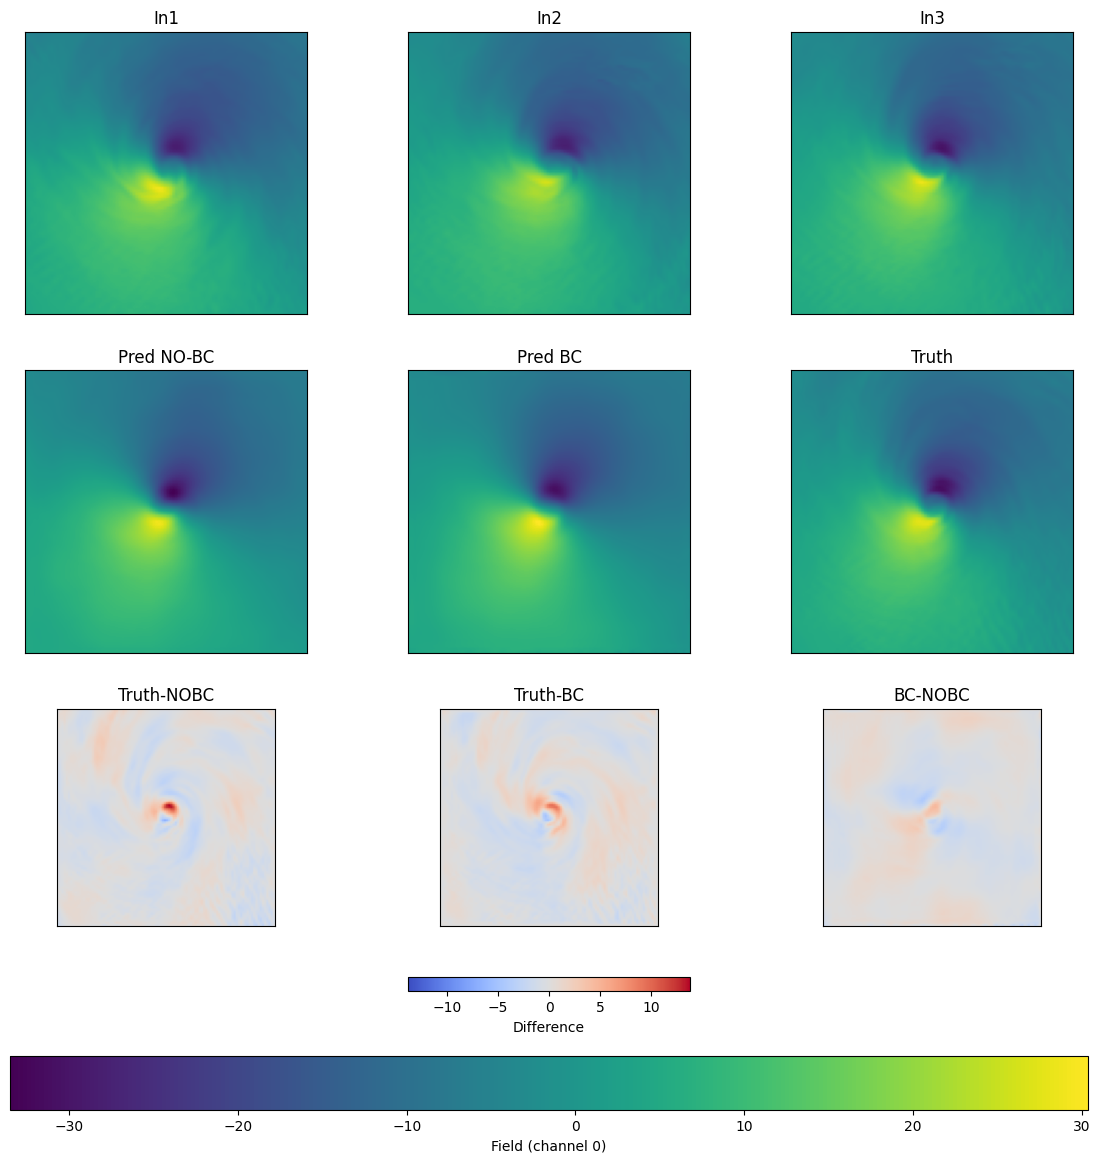

In [9]:
# ===== 12-panel figure (3 rows x 4 cols) =====
# Row 1: Inputs + Pred(BC)
#   [In1, In2, In3, Pred_BC]
# Row 2: Inputs + Pred(NO-BC)
#   [In1, In2, In3, Pred_NOBC]
# Row 3: Diagnostics (reordered)
#   [Truth-BC, Truth-NOBC, BC-NOBC, Truth]
# + ONE horizontal colorbar at the very bottom (fields)
# + ONE horizontal colorbar at the very bottom (diffs)

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---- User inputs ----
DS = "CMIP6"
DATA_SOURCE = f"/N/slate/kmluong/regDL-TCIP/{DS}/tmp"
SPLIT = "test"
SAMPLE_N = 150
SAMPLE_F = 0
CHANNEL_TO_SHOW = 0
RIM = 1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_CONFIG_PATH_BC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-BC.json"
MODEL_CHECKPOINT_PATH_BC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-BC.pt"

MODEL_CONFIG_PATH_NBC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-NO-BC.json"
MODEL_CHECKPOINT_PATH_NBC = f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-NO-BC.pt"

# ---- Helpers assumed available ----
# load_model_from_paths, load_split_arrays, extract_bc_rim_from_y, make_rim_mask_like, make_smooth_phi
# load_data_array, make_window_tensors

def _run_inference_one_window(model, x, y_true, use_bc: bool, rim: int = 1):
    with torch.no_grad():
        x_in = x
        y_in = y_true

        if getattr(model, "x_scaler", None) is not None:
            x_in = model.x_scaler.norm(x_in)
        if getattr(model, "y_scaler", None) is not None:
            y_in = model.y_scaler.norm(y_in)

        if use_bc:
            b_fill = extract_bc_rim_from_y(y_in, rim=rim)
            bc_mask = make_rim_mask_like(y_in, rim=rim)
            bc_in = torch.cat([b_fill, bc_mask], dim=1)

            y_free = model(x_in, bc_in)

            phi = make_smooth_phi(
                H=y_in.shape[-2], W=y_in.shape[-1], rim=rim,
                device=y_in.device, dtype=y_in.dtype,
            )
            y_pred_norm = phi * y_free + (1.0 - phi) * b_fill
        else:
            y_pred_norm = model(x_in)

        if getattr(model, "y_scaler", None) is not None:
            y_pred = model.y_scaler.denorm(y_pred_norm)
            y_ref = y_true
        else:
            y_pred = y_pred_norm
            y_ref = y_true

    return y_pred, y_ref

# ---- Load data ----
arr, _ = load_data_array(DATA_SOURCE, split=SPLIT)

# ---- Load models ----
model_bc, meta_bc = load_model_from_paths(
    config_path=MODEL_CONFIG_PATH_BC,
    checkpoint_path=MODEL_CHECKPOINT_PATH_BC,
    map_location=DEVICE,
    strict=True,
    eval_mode=True,
)
model_bc = model_bc.to(DEVICE)
step_in_bc = int(meta_bc["config"]["num_times"])

model_nbc, meta_nbc = load_model_from_paths(
    config_path=MODEL_CONFIG_PATH_NBC,
    checkpoint_path=MODEL_CHECKPOINT_PATH_NBC,
    map_location=DEVICE,
    strict=True,
    eval_mode=True,
)
model_nbc = model_nbc.to(DEVICE)
step_in_nbc = int(meta_nbc["config"]["num_times"])

# ---- Build window ----
step_in = min(step_in_bc, step_in_nbc)
x, y_true = make_window_tensors(arr, SAMPLE_N, SAMPLE_F, step_in=step_in, device=DEVICE)

T = x.shape[1]
if T < 3:
    raise ValueError("Need >=3 input frames")

c = int(CHANNEL_TO_SHOW)

# Inputs + truth
in_maps = [x[0, t, c].detach().cpu().numpy() for t in range(3)]
truth_map = y_true[0, c].detach().cpu().numpy()

# ---- Predict ----
y_pred_bc, _ = _run_inference_one_window(model_bc, x, y_true, use_bc=True, rim=RIM)
y_pred_nbc, _ = _run_inference_one_window(model_nbc, x, y_true, use_bc=False, rim=RIM)

pred_bc_map = y_pred_bc[0, c].detach().cpu().numpy()
pred_nbc_map = y_pred_nbc[0, c].detach().cpu().numpy()

# ---- Diagnostics (reordered) ----
d_truth_bc = truth_map - pred_bc_map
d_truth_nbc = truth_map - pred_nbc_map
d_bc_nbc = pred_bc_map - pred_nbc_map

# ---- Color scales ----
field_maps = in_maps + [pred_bc_map, pred_nbc_map, truth_map]
vmin = min(m.min() for m in field_maps)
vmax = max(m.max() for m in field_maps)

diff_maps = [d_truth_bc, d_truth_nbc, d_bc_nbc]
dmax = max(float(np.max(np.abs(m))) for m in diff_maps)
d_vmin, d_vmax = -dmax, dmax

# ---- Plot (3x3 layout) ----
fig, axes = plt.subplots(3, 3, figsize=(14, 14), sharex=True, sharey=True)

# =========================
# Row 1: Inputs
# =========================
for j in range(3):
    im_field = axes[0, j].imshow(
        in_maps[j], origin="lower", vmin=vmin, vmax=vmax, cmap="viridis"
    )

# =========================
# Row 2: Predictions + Truth
# =========================
axes[1, 0].imshow(pred_nbc_map, origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")
axes[1, 1].imshow(pred_bc_map, origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")
axes[1, 2].imshow(truth_map,   origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")

# =========================
# Row 3: Diagnostics
# =========================
im_diff = axes[2, 0].imshow(
    d_truth_nbc, origin="lower", vmin=d_vmin, vmax=d_vmax, cmap="coolwarm"
)
axes[2, 1].imshow(
    d_truth_bc, origin="lower", vmin=d_vmin, vmax=d_vmax, cmap="coolwarm"
)
axes[2, 2].imshow(
    d_bc_nbc, origin="lower", vmin=d_vmin, vmax=d_vmax, cmap="coolwarm"
)

# =========================
# Titles
# =========================
titles = [
    ["In1", "In2", "In3"],
    ["Pred NO-BC", "Pred BC", "Truth"],
    ["Truth-NOBC", "Truth-BC", "BC-NOBC"],
]
for i in range(3):
    for j in range(3):
        axes[i, j].set_title(titles[i][j])

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

# =========================
# Horizontal colorbars
# =========================
cbar1 = fig.colorbar(
    im_field,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.06,
)
cbar1.set_label(f"Field (channel {c})")

cbar2 = fig.colorbar(
    im_diff,
    ax=axes[2, :].ravel().tolist(),
    orientation="horizontal",
    fraction=0.05,
    pad=0.18,
)
cbar2.set_label("Difference")

plt.savefig("visualization.png", dpi=200, bbox_inches="tight")

In [10]:
import pandas as pd
import numpy as np

# =========================
# Convert tensors → numpy
# =========================
pred_np = y_pred_bc.detach().cpu().numpy()   # shape: (B, C, H, W)
truth_np = y_true.detach().cpu().numpy()

# =========================
# Remove batch dim
# =========================
pred_np = pred_np[0]    # (C, H, W)
truth_np = truth_np[0]

C = pred_np.shape[0]

# =========================
# Compute stats per channel
# =========================
rows = []

for c in range(C):
    p = pred_np[c]
    t = truth_np[c]

    pred_max = np.max(p)
    pred_min = np.min(p)

    truth_max = np.max(t)
    truth_min = np.min(t)

    rows.append({
        "channel": c,
        "pred_max": pred_max,
        "pred_min": pred_min,
        "truth_max": truth_max,
        "truth_min": truth_min,
        "max_diff": pred_max - truth_max,
        "min_diff": pred_min - truth_min,
    })

df_stats = pd.DataFrame(rows)

# =========================
# Display
# =========================
display(df_stats)

,channel,pred_max,pred_min,truth_max,truth_min,max_diff,min_diff
0,0,30.371447,-31.273552,27.812729,-31.329388,2.558718,0.055836
1,1,34.537674,-31.040529,36.093178,-29.605051,-1.555504,-1.435478
2,2,301.333130,298.184814,301.295929,298.184814,0.037201,0.000000
3,3,0.020175,-0.010883,0.000000,0.000000,0.020175,-0.010883
4,4,19.153484,-15.677185,30.086147,-22.630009,-10.932663,6.952824
5,5,22.682791,-14.722121,31.757996,-22.468246,-9.075205,7.746125
6,6,43.551086,-45.809170,44.444557,-48.364136,-0.893471,2.554966
7,7,50.554806,-43.797138,54.977676,-42.758625,-4.422871,-1.038513
8,8,54.957268,42.154491,54.461723,42.241676,0.495544,-0.087185
9,9,0.015707,0.001678,0.015360,0.001931,0.000346,-0.000253


import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

# =========================================================
# Config
# =========================================================
MODEL_KIND = "NO-BC"   # "BC" or "NO-BC"
RIM = 1

# Optional: give channel names if you have them
CHANNEL_NAMES = None
# Example:
# CHANNEL_NAMES = ["u10", "v10", "t2", ...]

# =========================================================
# Select model
# =========================================================
if MODEL_KIND.upper() == "BC":
    model = model_bc
    use_bc = True
    meta = meta_bc
elif MODEL_KIND.upper() == "NO-BC":
    model = model_nbc
    use_bc = False
    meta = meta_nbc
else:
    raise ValueError("MODEL_KIND must be 'BC' or 'NO-BC'")

model = model.to(DEVICE)
model.eval()

step_in = int(meta["config"]["num_times"])

# =========================================================
# Helper: infer how many valid windows exist
# Assumption from your make_window_tensors():
#   x uses [f : f+step_in]
#   y uses next frame at [f+step_in]
# so valid f are 0 ... T-step_in-1
# =========================================================
num_total_frames = arr.shape[1]
num_samples = arr.shape[0]
num_valid_f = num_total_frames - step_in

if num_valid_f <= 0:
    raise ValueError(
        f"Not enough frames in arr to build windows: "
        f"num_total_frames={num_total_frames}, step_in={step_in}"
    )

print(f"MODEL_KIND      : {MODEL_KIND}")
print(f"num_samples (N) : {num_samples}")
print(f"num_frames (F)  : {num_total_frames}")
print(f"step_in         : {step_in}")
print(f"valid windows/sample: {num_valid_f}")
print(f"total windows   : {num_samples * num_valid_f}")

# =========================================================
# Main loop
# =========================================================
rows = []

with torch.no_grad():
    for n in tqdm(range(num_samples), desc="Samples"):
        for f in range(num_valid_f):
            # Build one window
            x, y_true = make_window_tensors(arr, n, f, step_in=step_in, device=DEVICE)

            # Run inference
            y_pred, y_ref = _run_inference_one_window(
                model=model,
                x=x,
                y_true=y_true,
                use_bc=use_bc,
                rim=RIM,
            )

            # Convert to numpy
            pred_np = y_pred[0].detach().cpu().numpy()   # (C, H, W)
            truth_np = y_ref[0].detach().cpu().numpy()   # (C, H, W)

            C = pred_np.shape[0]

            # Per-channel stats for this sample/window
            for c in range(C):
                p = pred_np[c]
                t = truth_np[c]

                pred_max = float(np.max(p))
                pred_min = float(np.min(p))
                truth_max = float(np.max(t))
                truth_min = float(np.min(t))

                rows.append({
                    "sample_n": n,
                    "sample_f": f,
                    "channel": c,
                    "channel_name": CHANNEL_NAMES[c] if CHANNEL_NAMES is not None and c < len(CHANNEL_NAMES) else f"ch_{c}",
                    "pred_max": pred_max,
                    "pred_min": pred_min,
                    "truth_max": truth_max,
                    "truth_min": truth_min,
                    "max_diff": pred_max - truth_max,
                    "min_diff": pred_min - truth_min,
                })

# =========================================================
# Detailed table
# =========================================================
df_all_samples = pd.DataFrame(rows)

print("\nDetailed per-sample table:")
display(df_all_samples.head())

print(f"df_all_samples shape = {df_all_samples.shape}")

# =========================================================
# Aggregate statistics per channel
# =========================================================
def q05(x): return x.quantile(0.05)
def q25(x): return x.quantile(0.25)
def q50(x): return x.quantile(0.50)
def q75(x): return x.quantile(0.75)
def q95(x): return x.quantile(0.95)

summary = (
    df_all_samples
    .groupby(["channel", "channel_name"], as_index=False)
    .agg(
        n_samples=("channel", "size"),

        pred_max_mean=("pred_max", "mean"),
        pred_max_std=("pred_max", "std"),
        pred_max_min=("pred_max", "min"),
        pred_max_q05=("pred_max", q05),
        pred_max_median=("pred_max", q50),
        pred_max_q95=("pred_max", q95),
        pred_max_max=("pred_max", "max"),

        pred_min_mean=("pred_min", "mean"),
        pred_min_std=("pred_min", "std"),
        pred_min_min=("pred_min", "min"),
        pred_min_q05=("pred_min", q05),
        pred_min_median=("pred_min", q50),
        pred_min_q95=("pred_min", q95),
        pred_min_max=("pred_min", "max"),

        truth_max_mean=("truth_max", "mean"),
        truth_max_std=("truth_max", "std"),
        truth_max_min=("truth_max", "min"),
        truth_max_q05=("truth_max", q05),
        truth_max_median=("truth_max", q50),
        truth_max_q95=("truth_max", q95),
        truth_max_max=("truth_max", "max"),

        truth_min_mean=("truth_min", "mean"),
        truth_min_std=("truth_min", "std"),
        truth_min_min=("truth_min", "min"),
        truth_min_q05=("truth_min", q05),
        truth_min_median=("truth_min", q50),
        truth_min_q95=("truth_min", q95),
        truth_min_max=("truth_min", "max"),

        max_diff_mean=("max_diff", "mean"),
        max_diff_std=("max_diff", "std"),
        max_diff_min=("max_diff", "min"),
        max_diff_q05=("max_diff", q05),
        max_diff_q25=("max_diff", q25),
        max_diff_median=("max_diff", q50),
        max_diff_q75=("max_diff", q75),
        max_diff_q95=("max_diff", q95),
        max_diff_max=("max_diff", "max"),
        max_diff_abs_mean=("max_diff", lambda x: np.mean(np.abs(x))),

        min_diff_mean=("min_diff", "mean"),
        min_diff_std=("min_diff", "std"),
        min_diff_min=("min_diff", "min"),
        min_diff_q05=("min_diff", q05),
        min_diff_q25=("min_diff", q25),
        min_diff_median=("min_diff", q50),
        min_diff_q75=("min_diff", q75),
        min_diff_q95=("min_diff", q95),
        min_diff_max=("min_diff", "max"),
        min_diff_abs_mean=("min_diff", lambda x: np.mean(np.abs(x))),
    )
    .sort_values("channel")
    .reset_index(drop=True)
)

df_summary = summary

print("\nAggregated statistics per channel:")
display(df_summary)

# =========================================================
# Optional saves
# =========================================================
df_all_samples.to_csv(f"all_samples_channel_extrema_{MODEL_KIND.lower()}.csv", index=False)
df_summary.to_csv(f"summary_channel_extrema_{MODEL_KIND.lower()}.csv", index=False)

print(f"\nSaved:")
print(f"  all_samples_channel_extrema_{MODEL_KIND.lower()}.csv")
print(f"  summary_channel_extrema_{MODEL_KIND.lower()}.csv")

In [14]:
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

# =========================================================
# Config
# =========================================================
MODEL_KIND = "NO-BC"   # "BC" or "NO-BC"
RIM = 1

# Optional: give channel names if you have them
CHANNEL_NAMES = None

# Derived wind-speed channel definitions
DERIVED_WIND_CHANNELS = [
    {"name": "wind10", "u_idx": 0, "v_idx": 1},
    {"name": "wind28", "u_idx": 4, "v_idx": 5},
    {"name": "wind05", "u_idx": 6, "v_idx": 7},
]

# =========================================================
# Select model
# =========================================================
if MODEL_KIND.upper() == "BC":
    model = model_bc
    use_bc = True
    meta = meta_bc
elif MODEL_KIND.upper() == "NO-BC":
    model = model_nbc
    use_bc = False
    meta = meta_nbc
else:
    raise ValueError("MODEL_KIND must be 'BC' or 'NO-BC'")

model = model.to(DEVICE)
model.eval()

step_in = int(meta["config"]["num_times"])

# =========================================================
# Helper: infer how many valid windows exist
# =========================================================
num_total_frames = arr.shape[1]
num_samples = arr.shape[0]
num_valid_f = num_total_frames - step_in

if num_valid_f <= 0:
    raise ValueError(
        f"Not enough frames in arr to build windows: "
        f"num_total_frames={num_total_frames}, step_in={step_in}"
    )

print(f"MODEL_KIND      : {MODEL_KIND}")
print(f"num_samples (N) : {num_samples}")
print(f"num_frames (F)  : {num_total_frames}")
print(f"step_in         : {step_in}")
print(f"valid windows/sample: {num_valid_f}")
print(f"total windows   : {num_samples * num_valid_f}")

# =========================================================
# Main loop
# =========================================================
rows = []

with torch.no_grad():
    for n in tqdm(range(num_samples), desc="Samples"):
        for f in range(num_valid_f):
            # Build one window
            x, y_true = make_window_tensors(arr, n, f, step_in=step_in, device=DEVICE)

            # Run inference
            y_pred, y_ref = _run_inference_one_window(
                model=model,
                x=x,
                y_true=y_true,
                use_bc=use_bc,
                rim=RIM,
            )

            # Convert to numpy
            pred_np = y_pred[0].detach().cpu().numpy()   # (C, H, W)
            truth_np = y_ref[0].detach().cpu().numpy()   # (C, H, W)

            C = pred_np.shape[0]

            # -------------------------------------------------
            # 1) Original per-channel stats
            # -------------------------------------------------
            for c in range(C):
                p = pred_np[c]
                t = truth_np[c]

                pred_max = float(np.max(p))
                pred_min = float(np.min(p))
                truth_max = float(np.max(t))
                truth_min = float(np.min(t))

                rows.append({
                    "sample_n": n,
                    "sample_f": f,
                    "channel": c,
                    "channel_name": (
                        CHANNEL_NAMES[c]
                        if CHANNEL_NAMES is not None and c < len(CHANNEL_NAMES)
                        else f"ch_{c}"
                    ),
                    "is_derived": False,
                    "pred_max": pred_max,
                    "pred_min": pred_min,
                    "truth_max": truth_max,
                    "truth_min": truth_min,
                    "max_diff": pred_max - truth_max,
                    "min_diff": pred_min - truth_min,
                })

            # -------------------------------------------------
            # 2) Derived wind speed channels
            #    CORRECT PHYSICS:
            #    speed = sqrt(u^2 + v^2) at each grid point,
            #    then take max over the field
            # -------------------------------------------------
            for d in DERIVED_WIND_CHANNELS:
                u_idx = d["u_idx"]
                v_idx = d["v_idx"]
                name = d["name"]

                if max(u_idx, v_idx) >= C:
                    continue

                pred_u = pred_np[u_idx]
                pred_v = pred_np[v_idx]
                truth_u = truth_np[u_idx]
                truth_v = truth_np[v_idx]

                pred_speed = np.sqrt(pred_u**2 + pred_v**2)
                truth_speed = np.sqrt(truth_u**2 + truth_v**2)

                pred_max = float(np.max(pred_speed))
                truth_max = float(np.max(truth_speed))

                rows.append({
                    "sample_n": n,
                    "sample_f": f,
                    "channel": -1,
                    "channel_name": name,
                    "is_derived": True,
                    "pred_max": pred_max,
                    "pred_min": np.nan,
                    "truth_max": truth_max,
                    "truth_min": np.nan,
                    "max_diff": pred_max - truth_max,
                    "min_diff": np.nan,
                })

# =========================================================
# Detailed table
# =========================================================
df_all_samples = pd.DataFrame(rows)

print("\nDetailed per-sample table:")
display(df_all_samples.head())
print(f"df_all_samples shape = {df_all_samples.shape}")

# =========================================================
# Aggregate statistics per channel
# =========================================================
def q05(x): return x.quantile(0.05)
def q25(x): return x.quantile(0.25)
def q50(x): return x.quantile(0.50)
def q75(x): return x.quantile(0.75)
def q95(x): return x.quantile(0.95)

summary = (
    df_all_samples
    .groupby(["channel", "channel_name", "is_derived"], as_index=False)
    .agg(
        n_samples=("channel_name", "size"),

        pred_max_mean=("pred_max", "mean"),
        pred_max_std=("pred_max", "std"),
        pred_max_min=("pred_max", "min"),
        pred_max_q05=("pred_max", q05),
        pred_max_median=("pred_max", q50),
        pred_max_q95=("pred_max", q95),
        pred_max_max=("pred_max", "max"),

        pred_min_mean=("pred_min", "mean"),
        pred_min_std=("pred_min", "std"),
        pred_min_min=("pred_min", "min"),
        pred_min_q05=("pred_min", q05),
        pred_min_median=("pred_min", q50),
        pred_min_q95=("pred_min", q95),
        pred_min_max=("pred_min", "max"),

        truth_max_mean=("truth_max", "mean"),
        truth_max_std=("truth_max", "std"),
        truth_max_min=("truth_max", "min"),
        truth_max_q05=("truth_max", q05),
        truth_max_median=("truth_max", q50),
        truth_max_q95=("truth_max", q95),
        truth_max_max=("truth_max", "max"),

        truth_min_mean=("truth_min", "mean"),
        truth_min_std=("truth_min", "std"),
        truth_min_min=("truth_min", "min"),
        truth_min_q05=("truth_min", q05),
        truth_min_median=("truth_min", q50),
        truth_min_q95=("truth_min", q95),
        truth_min_max=("truth_min", "max"),

        max_diff_mean=("max_diff", "mean"),
        max_diff_std=("max_diff", "std"),
        max_diff_min=("max_diff", "min"),
        max_diff_q05=("max_diff", q05),
        max_diff_q25=("max_diff", q25),
        max_diff_median=("max_diff", q50),
        max_diff_q75=("max_diff", q75),
        max_diff_q95=("max_diff", q95),
        max_diff_max=("max_diff", "max"),
        max_diff_abs_mean=("max_diff", lambda x: np.mean(np.abs(x))),

        min_diff_mean=("min_diff", "mean"),
        min_diff_std=("min_diff", "std"),
        min_diff_min=("min_diff", "min"),
        min_diff_q05=("min_diff", q05),
        min_diff_q25=("min_diff", q25),
        min_diff_median=("min_diff", q50),
        min_diff_q75=("min_diff", q75),
        min_diff_q95=("min_diff", q95),
        min_diff_max=("min_diff", "max"),
        min_diff_abs_mean=("min_diff", lambda x: np.mean(np.abs(x))),
    )
    .sort_values(["is_derived", "channel_name", "channel"])
    .reset_index(drop=True)
)

df_summary = summary

print("\nAggregated statistics per channel:")
display(df_summary)

# =========================================================
# Saves
# =========================================================
df_all_samples.to_csv(f"all_samples_channel_extrema_{MODEL_KIND.lower()}.csv", index=False)
df_summary.to_csv(f"summary_channel_extrema_{MODEL_KIND.lower()}.csv", index=False)

print(f"\nSaved:")
print(f"  all_samples_channel_extrema_{MODEL_KIND.lower()}.csv")
print(f"  summary_channel_extrema_{MODEL_KIND.lower()}.csv")

MODEL_KIND      : NO-BC
num_samples (N) : 273
num_frames (F)  : 5
step_in         : 3
valid windows/sample: 2
total windows   : 546


Samples: 100%|██████████| 273/273 [08:26<00:00,  1.86s/it]


Detailed per-sample table:


,sample_n,sample_f,channel,channel_name,is_derived,pred_max,pred_min,truth_max,truth_min,max_diff,min_diff
0,0,0,0,ch_0,False,14.051183,-14.626635,20.701738,-25.548744,-6.650556,10.922110
1,0,0,1,ch_1,False,15.456435,-13.811128,28.789564,-21.746817,-13.333129,7.935689
2,0,0,2,ch_2,False,303.186676,301.246277,303.225037,296.148621,-0.038361,5.097656
3,0,0,3,ch_3,False,0.031071,-0.029678,1.000000,0.000000,-0.968929,-0.029678
4,0,0,4,ch_4,False,16.130947,-13.712927,23.161537,-21.409512,-7.030590,7.696585


df_all_samples shape = (8190, 11)

Aggregated statistics per channel:


,channel,channel_name,is_derived,n_samples,pred_max_mean,pred_max_std,pred_max_min,pred_max_q05,pred_max_median,pred_max_q95,...,min_diff_mean,min_diff_std,min_diff_min,min_diff_q05,min_diff_q25,min_diff_median,min_diff_q75,min_diff_q95,min_diff_max,min_diff_abs_mean
0,0,ch_0,False,546,23.863738,8.990558,-0.268801,8.758205,24.197094,37.424342,...,5.240013,5.677511,-9.347044,-2.108885,1.274971,4.193577,8.647722,15.997498,27.057333,5.847618
1,1,ch_1,False,546,25.779020,9.578147,5.265827,8.346004,26.107643,40.658537,...,5.383639,5.759533,-8.532450,-2.454777,1.454633,4.455972,8.421373,16.143618,32.805773,5.983317
2,10,ch_10,False,546,22046.039442,4827.643979,18582.511719,19814.779785,19930.021484,33895.524414,...,39.562396,71.425261,-187.753906,-67.640625,-2.946289,36.905273,79.537598,156.723633,399.792969,61.786698
3,11,ch_11,False,546,101106.442508,299.618600,100275.742188,100646.343750,101109.878906,101608.785156,...,1189.629536,2407.551290,-4362.843750,-522.525391,-101.767578,436.917969,1350.626953,6859.886719,18167.296875,1407.374099
4,2,ch_2,False,546,302.242301,1.578350,289.777588,300.862206,302.432831,303.599777,...,1.532319,1.979076,-2.087677,-0.464737,0.041389,0.867676,2.001205,5.402191,6.953186,1.667812
5,3,ch_3,False,546,0.257578,0.417121,0.014896,0.020102,0.035408,1.120895,...,-0.035592,0.015906,-0.151084,-0.060846,-0.038455,-0.032613,-0.026622,-0.020952,-0.014979,0.035592
6,4,ch_4,False,546,18.607008,11.165356,-1.814466,5.504252,17.881161,28.550301,...,6.597429,6.363175,-16.094635,-2.172544,2.351529,5.828062,10.428654,17.322933,40.646616,7.267705
7,5,ch_5,False,546,19.161526,7.408074,-6.294566,7.571704,19.255682,31.358963,...,6.106018,5.870142,-11.139483,-1.589924,1.959673,5.100077,9.481294,16.810806,30.016904,6.591596
8,6,ch_6,False,546,33.465609,13.500485,0.119130,11.408733,33.766163,54.622731,...,6.628746,8.029551,-15.483101,-3.543938,1.111500,5.154634,10.727868,22.129803,40.075104,7.755463
9,7,ch_7,False,546,36.948164,14.478188,6.044220,11.242381,36.862566,60.089835,...,7.171529,8.302377,-17.101376,-4.172762,1.615909,5.828199,11.217870,23.150433,49.493315,8.254841



Saved:
  all_samples_channel_extrema_no-bc.csv
  summary_channel_extrema_no-bc.csv
